# Exploratory Evaluation and Visualization Gallery

**Status: EXPLORATORY.** Every metric and figure below is a *candidate* for the final
research report. Nothing here has been selected for inclusion, and several of these
will probably be dropped after review.

No model is rerun, retrained or regenerated in this notebook. Every number comes from
retained artifacts already in the repository, via `scripts/exploratory_evaluation.py`.

Each figure is labelled **HIGH / MEDIUM / OPTIONAL** with a short note on what it shows,
why it may be useful, and whether it is a headline, diagnostic or sensitivity figure.

**Complete 12-round specifications evaluated:** RF/no-KNN, RF/KNN, LightGBM/no-KNN,
Softmax/KNN, Chronos-2 (copula), Chronos-2 (independent), Financial Chronos 46M,
Chronos-T5 Base 200M, and the naive 0.2-each benchmark.

**Deliberately excluded from all aggregates:** LightGBM/KNN, which was stopped at M6
round 11 by an invalid adjusted probability and therefore has no 12-round forecast.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))
import exploratory_evaluation as ev

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "figure.autolayout": False,
})

FEATURE_C, TSFM_C, NAIVE_C = "#2C6E9B", "#C1553B", "#6B6B6B"
COLOR = {m: (FEATURE_C if f == "Feature-based" else TSFM_C if f == "TSFM" else NAIVE_C)
         for m, f in ev.FAMILY.items()}

truth = ev.load_ground_truth()
forecasts = ev.load_probability_forecasts(truth)
metrics = pd.read_csv(ROOT / "Results/Evaluation/exploratory_model_metrics.csv")
rmse = pd.read_csv(ROOT / "Results/Evaluation/exploratory_tsfm_return_rmse.csv")
by_round = ev.per_round_metrics(forecasts, truth)
NAIVE = 0.16

print(f"{len(forecasts)} complete specifications | {len(truth)} asset-round observations")
metrics[["model", "family", "rps", "accuracy", "macro_roc_auc", "ece_5bin"]]

9 complete specifications | 1200 asset-round observations


,model,family,rps,accuracy,macro_roc_auc,ece_5bin
0,RF / no-KNN,Feature-based,0.157053,0.265000,0.610227,0.004659
1,RF / KNN,Feature-based,0.157149,0.259167,0.608622,0.015520
2,LightGBM / no-KNN,Feature-based,0.157432,0.258333,0.604776,0.011735
3,Softmax / KNN,Feature-based,0.157355,0.270000,0.611991,0.007605
4,Chronos-2 120M (copula),TSFM,0.165418,0.265833,0.599221,0.045857
5,Chronos-2 120M (independent),TSFM,0.165559,0.247500,0.585993,0.065200
6,Financial Chronos 46M,TSFM,0.179368,0.223333,0.533816,0.172792
7,Chronos-T5 Base 200M,TSFM,0.226899,0.229167,0.539824,0.299908
8,Naive (0.2 each),Benchmark,0.160000,0.200000,0.500000,0.000000


---
## A. Overall RPS model comparison — **HIGH**

**What it shows.** Mean official M6 RPS over the 12 held-out rounds for every complete
specification, with the naive benchmark marked. Colour separates feature-based
classifiers from TSFMs.

**Why it may be useful.** This is the project's primary metric and its headline result:
the feature-based family sits below the naive line, every TSFM sits above it.

**Type:** headline result.

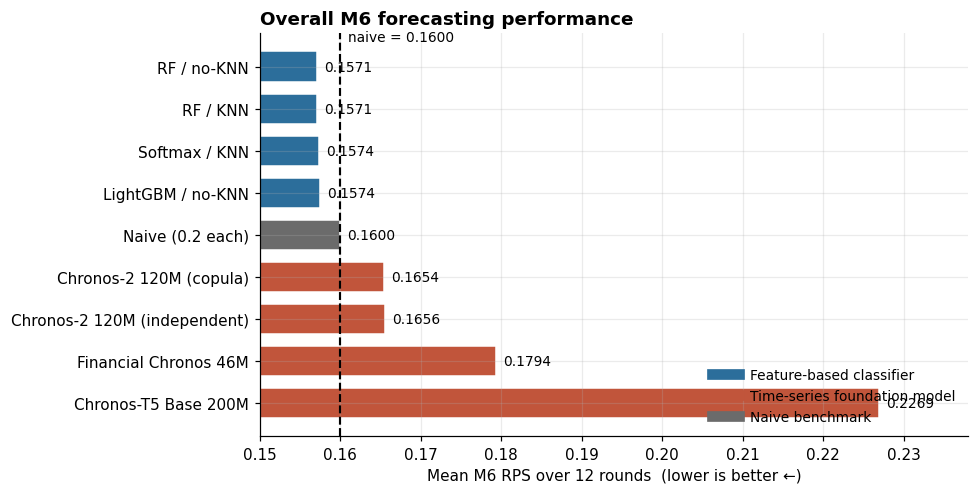

In [2]:
order = metrics.sort_values("rps")
fig, ax = plt.subplots(figsize=(9, 4.6))
bars = ax.barh(order["model"], order["rps"],
               color=[COLOR[m] for m in order["model"]], edgecolor="white", height=0.72)
ax.axvline(NAIVE, color="black", ls="--", lw=1.4, zorder=3)
ax.text(NAIVE + 0.0009, -0.62, "naive = 0.1600", fontsize=9, color="black")
for bar, value in zip(bars, order["rps"]):
    ax.text(value + 0.0009, bar.get_y() + bar.get_height() / 2, f"{value:.4f}",
            va="center", fontsize=9)
ax.set_xlim(0.150, 0.238)
ax.invert_yaxis()
ax.set_xlabel("Mean M6 RPS over 12 rounds  (lower is better ←)")
ax.set_title("Overall M6 forecasting performance", fontweight="bold", loc="left")
ax.legend(handles=[Line2D([], [], color=FEATURE_C, lw=7, label="Feature-based classifier"),
                   Line2D([], [], color=TSFM_C, lw=7, label="Time-series foundation model"),
                   Line2D([], [], color=NAIVE_C, lw=7, label="Naive benchmark")],
          loc="lower right", frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

---
## B. RPS across the 12 M6 rounds — **HIGH**

**What it shows.** Temporal variation in performance. Split into two panels so nine
series never share one axis: feature-based models (which are nearly coincident) on the
left, TSFMs on the right, with the naive line and the same y-scale on both.

**Why it may be useful.** It shows whether the aggregate ranking is stable through time
or driven by a few rounds, and makes the very different spread of the two families
visible.

**Type:** headline result with a diagnostic element.

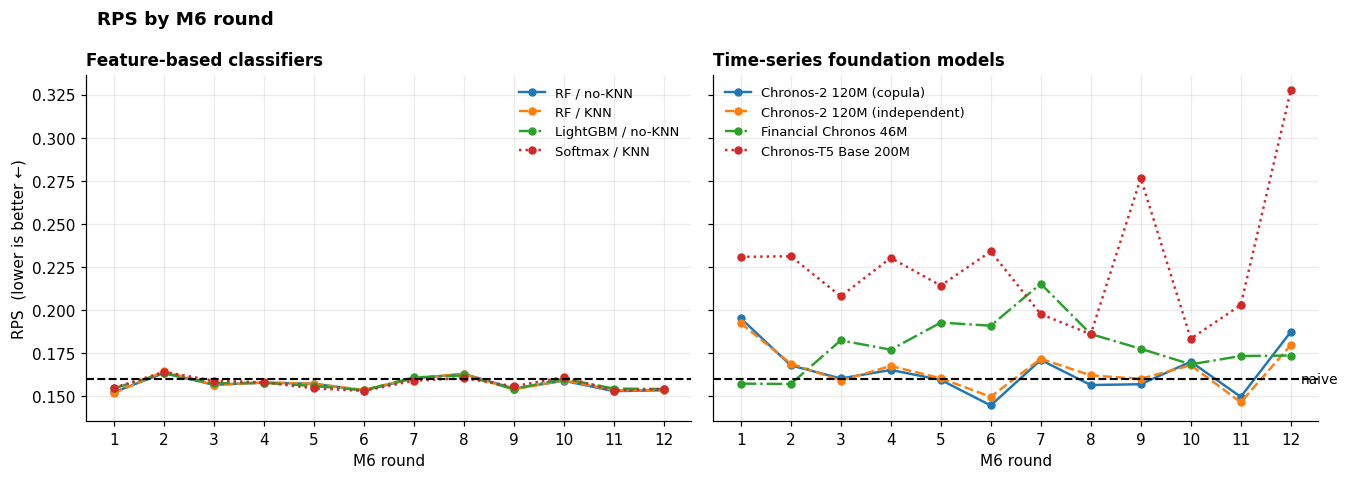

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4), sharey=True)
groups = [("Feature-based classifiers", [m for m in ev.MODEL_ORDER if ev.FAMILY[m] == "Feature-based"]),
          ("Time-series foundation models", [m for m in ev.MODEL_ORDER if ev.FAMILY[m] == "TSFM"])]
styles = ["-", "--", "-.", ":"]
for ax, (title, models) in zip(axes, groups):
    for i, model in enumerate(models):
        block = by_round[by_round["model"] == model]
        ax.plot(block["round"], block["rps"], marker="o", ms=4.5, lw=1.6,
                ls=styles[i % len(styles)], label=model)
    ax.axhline(NAIVE, color="black", ls="--", lw=1.4)
    ax.set_title(title, fontsize=11, fontweight="bold", loc="left")
    ax.set_xlabel("M6 round"); ax.set_xticks(range(1, 13))
    ax.legend(fontsize=8.5, frameon=False)
axes[0].set_ylabel("RPS  (lower is better ←)")
axes[1].text(12.2, NAIVE, "naive", va="center", fontsize=9)
fig.suptitle("RPS by M6 round", fontweight="bold", x=0.075, ha="left")
plt.tight_layout(); plt.show()

---
## C. Calibration / reliability — **HIGH**

**What it shows.** Left: a reliability diagram — mean predicted confidence against
observed accuracy in each confidence bin, with the diagonal marking perfect
calibration. Points below the diagonal are overconfident. Right: ECE for every model
under three binnings, showing the result is not an artifact of bin choice.

**Why it may be useful.** This is the clearest explanation of *why* the TSFMs score
badly on RPS: they are heavily overconfident, not merely uninformative. It gives ECE a
visual interpretation.

**Type:** diagnostic, and arguably a headline explanatory figure.

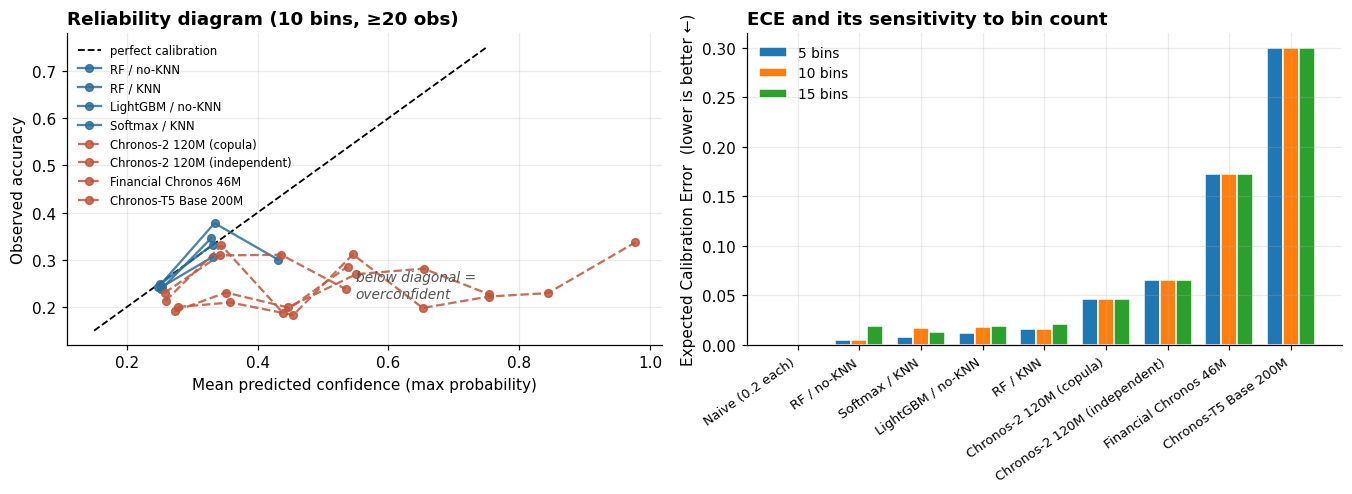

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6))
ax = axes[0]
ax.plot([0.15, 0.75], [0.15, 0.75], color="black", ls="--", lw=1.2, label="perfect calibration")
for model in ev.MODEL_ORDER:
    if model == "Naive (0.2 each)":
        continue
    probabilities = forecasts[model][ev.RANK_COLUMNS].to_numpy(float)
    curve = ev.reliability_curve(probabilities, truth["true_class"].to_numpy(), n_bins=10)
    curve = curve[curve["n"] >= 20]
    ax.plot(curve["mean_confidence"], curve["accuracy"], marker="o", ms=5, lw=1.5,
            color=COLOR[model], alpha=0.85,
            ls="-" if ev.FAMILY[model] == "Feature-based" else "--", label=model)
ax.set_xlabel("Mean predicted confidence (max probability)")
ax.set_ylabel("Observed accuracy")
ax.set_title("Reliability diagram (10 bins, ≥20 obs)", fontweight="bold", loc="left")
ax.legend(fontsize=7.6, frameon=False, loc="upper left")
ax.text(0.55, 0.22, "below diagonal =\noverconfident", fontsize=9, style="italic", color="#555")

ax = axes[1]
bins = ["ece_5bin", "ece_10bin", "ece_15bin"]
sub = metrics.sort_values("ece_5bin")
x = np.arange(len(sub)); width = 0.26
for i, column in enumerate(bins):
    ax.bar(x + (i - 1) * width, sub[column], width, label=column.replace("ece_", "").replace("bin", " bins"),
           edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(sub["model"], rotation=35, ha="right", fontsize=8.5)
ax.set_ylabel("Expected Calibration Error  (lower is better ←)")
ax.set_title("ECE and its sensitivity to bin count", fontweight="bold", loc="left")
ax.legend(fontsize=9, frameon=False)
plt.tight_layout(); plt.show()

---
## D. Discrimination (ROC-AUC) — **HIGH**

**What it shows.** Left: macro one-vs-rest ROC-AUC per model against the 0.5 no-skill
line. Right: the same broken out by quintile as a heatmap, rather than plotting 45 ROC
curves.

**Full ROC-AUC is used, not partial AUC**: this project has no independently motivated
false-positive-rate cutoff that would justify evaluating only part of the curve.

**Why it may be useful.** Read together with panel C it separates *discrimination* from
*calibration* — the two distinct ways a probabilistic forecast can be poor.

**Type:** diagnostic.

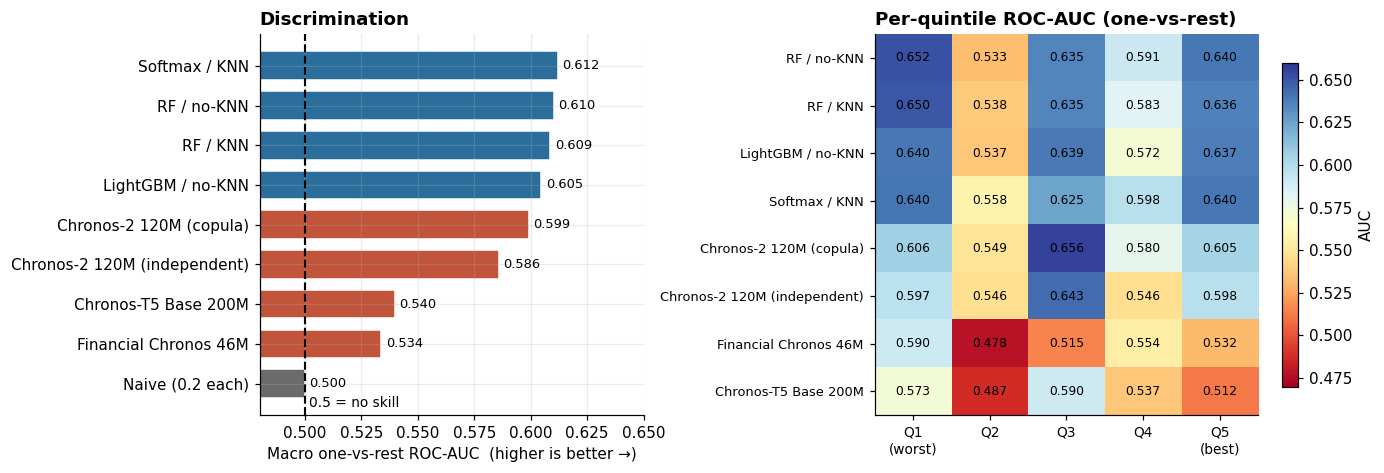

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4),
                         gridspec_kw={"width_ratios": [1, 1.25]})
ax = axes[0]
sub = metrics.sort_values("macro_roc_auc", ascending=False)
ax.barh(sub["model"], sub["macro_roc_auc"], color=[COLOR[m] for m in sub["model"]],
        edgecolor="white", height=0.72)
ax.axvline(0.5, color="black", ls="--", lw=1.4)
ax.text(0.502, len(sub) - 0.4, "0.5 = no skill", fontsize=9)
for i, value in enumerate(sub["macro_roc_auc"]):
    ax.text(value + 0.002, i, f"{value:.3f}", va="center", fontsize=8.5)
ax.set_xlim(0.48, 0.65); ax.invert_yaxis()
ax.set_xlabel("Macro one-vs-rest ROC-AUC  (higher is better →)")
ax.set_title("Discrimination", fontweight="bold", loc="left")

ax = axes[1]
cols = [f"roc_auc_q{i}" for i in range(1, 6)]
heat = metrics.set_index("model").loc[[m for m in ev.MODEL_ORDER if m != "Naive (0.2 each)"], cols]
im = ax.imshow(heat.to_numpy(), cmap="RdYlBu", vmin=0.47, vmax=0.66, aspect="auto")
ax.set_xticks(range(5))
ax.set_xticklabels(["Q1\n(worst)", "Q2", "Q3", "Q4", "Q5\n(best)"], fontsize=9)
ax.set_yticks(range(len(heat))); ax.set_yticklabels(heat.index, fontsize=8.5)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.iat[i, j]:.3f}", ha="center", va="center", fontsize=8)
ax.set_title("Per-quintile ROC-AUC (one-vs-rest)", fontweight="bold", loc="left")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.85, label="AUC")
plt.tight_layout(); plt.show()

---
## E. Confusion matrices — **HIGH**

**What it shows.** Row-normalised confusion matrices (true quintile x predicted
quintile) for four representative specifications — the best feature-based model, the
linear model, the best TSFM and the worst TSFM. Not all nine, to avoid duplication.

**Why it may be useful.** It reveals *where* argmax predictions concentrate. A model that
predicts mostly Q1/Q5, or collapses onto the middle, looks identical on accuracy but is
behaving very differently.

**Type:** diagnostic.

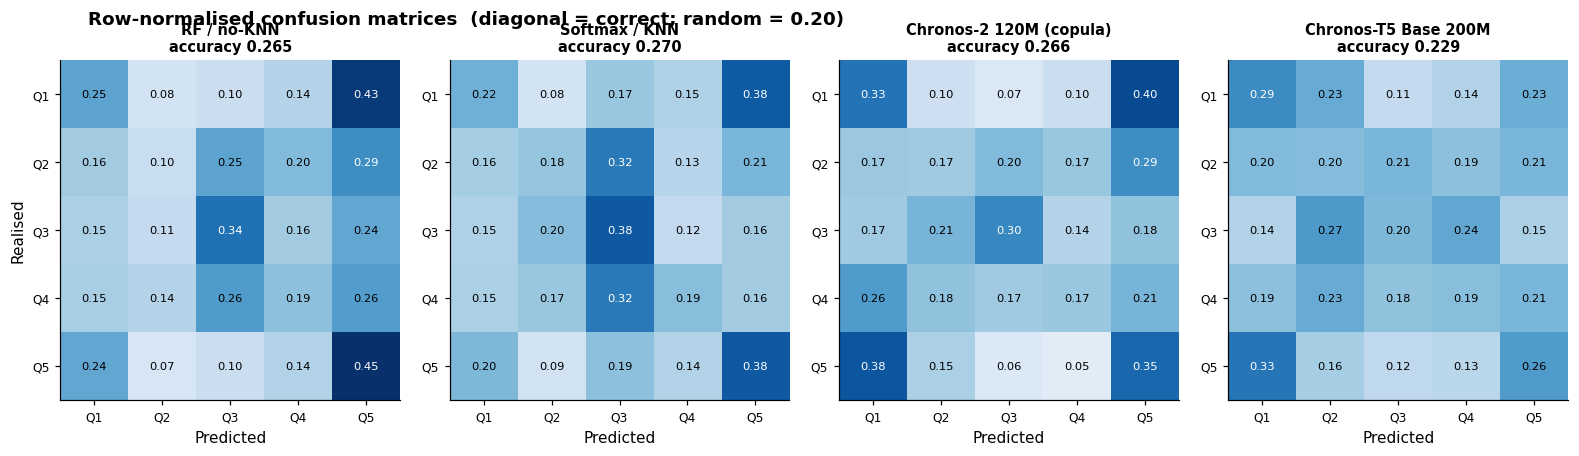

In [6]:
show = ["RF / no-KNN", "Softmax / KNN", "Chronos-2 120M (copula)", "Chronos-T5 Base 200M"]
fig, axes = plt.subplots(1, 4, figsize=(14.5, 3.9))
labels = ["Q1", "Q2", "Q3", "Q4", "Q5"]
for ax, model in zip(axes, show):
    probabilities = forecasts[model][ev.RANK_COLUMNS].to_numpy(float)
    predicted = probabilities.argmax(axis=1)
    actual = truth["true_class"].to_numpy()
    matrix = np.zeros((5, 5))
    for a, p in zip(actual, predicted):
        matrix[a, p] += 1
    matrix = matrix / matrix.sum(axis=1, keepdims=True)
    im = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=0.45)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", fontsize=7.5,
                    color="white" if matrix[i, j] > 0.28 else "black")
    accuracy = float(metrics.loc[metrics["model"] == model, "accuracy"].iloc[0])
    ax.set_title(f"{model}\naccuracy {accuracy:.3f}", fontsize=9.5, fontweight="bold")
    ax.set_xticks(range(5)); ax.set_xticklabels(labels, fontsize=8)
    ax.set_yticks(range(5)); ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Predicted"); ax.grid(False)
axes[0].set_ylabel("Realised")
fig.suptitle("Row-normalised confusion matrices  (diagonal = correct; random = 0.20)",
             fontweight="bold", x=0.06, ha="left")
plt.tight_layout(); plt.show()

---
## F. TSFM return RMSE vs forecast horizon — **HIGH**

**What it shows.** Left: *daily* RMSE — error in the return specifically h days ahead.
Right: *cumulative* RMSE — error in the total return accumulated from day 1 to day h.
The dashed grey line is the RMSE of forecasting exactly **zero**, which is the floor set
by the returns' own volatility.

These are two different questions and must not be conflated. Cumulative RMSE at h = 20
is the diagnostic most directly relevant to the four-week M6 target.

**Why it may be useful.** It is the clearest evidence on whether the TSFMs have any
numerical point-forecast skill, and later work may study horizon effects explicitly.

**Note.** RF/LightGBM/Softmax forecast quintile membership, not returns, so they have no
equivalent RMSE and are deliberately absent.

**Type:** diagnostic (TSFM-specific).

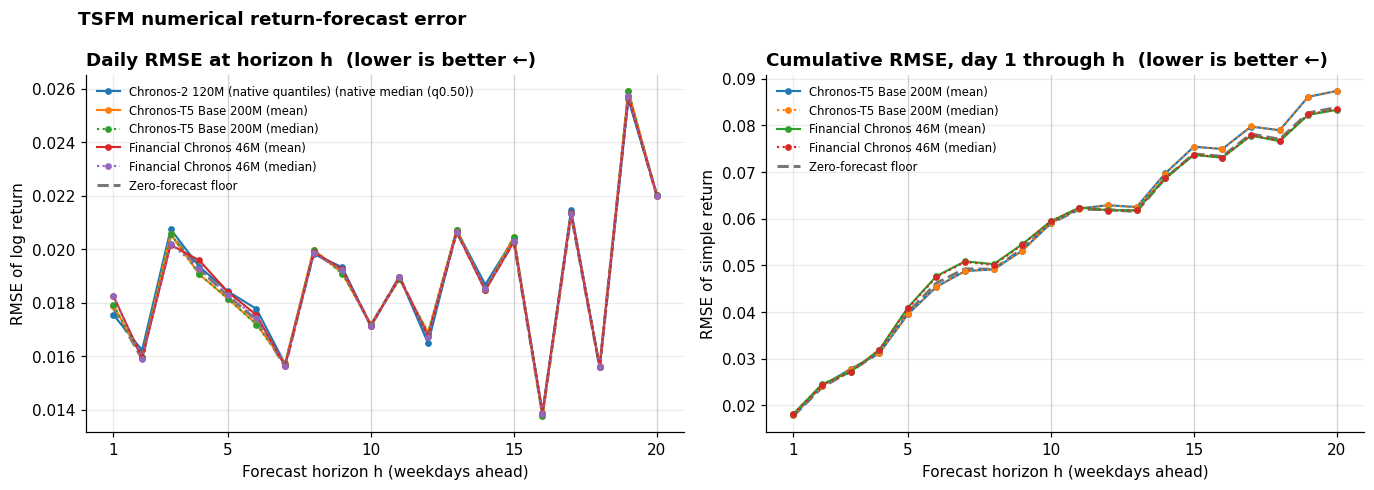

RMSE at the retained horizons 5 / 10 / 15 / 20:


rmse_type                                               cumulative            \
horizon                                                         5         10   
model                             point_forecast                               
Chronos-2 120M (native quantiles) native median (q0.50)        NaN       NaN   
Chronos-T5 Base 200M              mean                    0.039493  0.059067   
                                  median                  0.039472  0.059060   
Financial Chronos 46M             mean                    0.040929  0.059462   
                                  median                  0.040794  0.059417   
Zero-return baseline              zero                    0.039888  0.059020   

rmse_type                                                                    \
horizon                                                        15        20   
model                             point_forecast                              
Chronos-2 120M (native quantiles) native median (q0.50)       NaN       NaN   
Chronos-T5 Base 200M              mean                   0.075441  0.087414   
                                  median                 0.075441  0.087405   
Financial Chronos 46M             mean                   0.073698  0.083346   
                                  median                 0.073750  0.083490   
Zero-return baseline              zero                   0.073886  0.083859   

rmse_type                                                   daily            \
horizon                                                        5         10   
model                             point_forecast                              
Chronos-2 120M (native quantiles) native median (q0.50)  0.018427  0.017117   
Chronos-T5 Base 200M              mean                   0.018153  0.017200   
                                  median                 0.018156  0.017193   
Financial Chronos 46M             mean                   0.018402  0.017140   
                                  median                 0.018282  0.017139   
Zero-return baseline              zero                   0.018254  0.017159   

rmse_type                                                                    
horizon                                                        15        20  
model                             point_forecast                             
Chronos-2 120M (native quantiles) native median (q0.50)  0.020407  0.022039  
Chronos-T5 Base 200M              mean                   0.020465  0.022004  
                                  median                 0.020459  0.022007  
Financial Chronos 46M             mean                   0.020284  0.021995  
                                  median                 0.020293  0.022006  
Zero-return baseline              zero                   0.020293  0.021988

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.5))
for ax, kind, title in [(axes[0], "daily", "Daily RMSE at horizon h"),
                        (axes[1], "cumulative", "Cumulative RMSE, day 1 through h")]:
    block = rmse[rmse["rmse_type"] == kind]
    for (model, statistic), series in block.groupby(["model", "point_forecast"]):
        if model == "Zero-return baseline":
            ax.plot(series["horizon"], series["rmse"], color="#777", ls="--", lw=2,
                    label="Zero-forecast floor", zorder=1)
            continue
        ax.plot(series["horizon"], series["rmse"], marker="o", ms=3.4, lw=1.4,
                ls="-" if statistic in ("mean", "native median (q0.50)") else ":",
                label=f"{model} ({statistic})")
    ax.set_xlabel("Forecast horizon h (weekdays ahead)")
    ax.set_ylabel("RMSE of log return" if kind == "daily" else "RMSE of simple return")
    ax.set_title(title + "  (lower is better ←)", fontweight="bold", loc="left")
    ax.set_xticks([1, 5, 10, 15, 20])
    for h in (5, 10, 15, 20):
        ax.axvline(h, color="#DDD", lw=0.8, zorder=0)
    ax.legend(fontsize=7.6, frameon=False)
fig.suptitle("TSFM numerical return-forecast error", fontweight="bold", x=0.06, ha="left")
plt.tight_layout(); plt.show()

pivot = (rmse[rmse["horizon"].isin([5, 10, 15, 20])]
         .pivot_table(index=["model", "point_forecast"], columns=["rmse_type", "horizon"],
                      values="rmse").round(6))
print("RMSE at the retained horizons 5 / 10 / 15 / 20:")
pivot

---
## G. RF: KNN vs no-KNN — **MEDIUM (sensitivity)**

**What it shows.** Round-by-round RPS for the two preprocessing branches of Random
Forest, and their aggregate gap.

**Why it may be useful.** The two-pipeline design existed specifically to test whether
Samartzis-style KNN imputation of missing returns matters. This figure answers that
question directly.

**Type:** sensitivity.

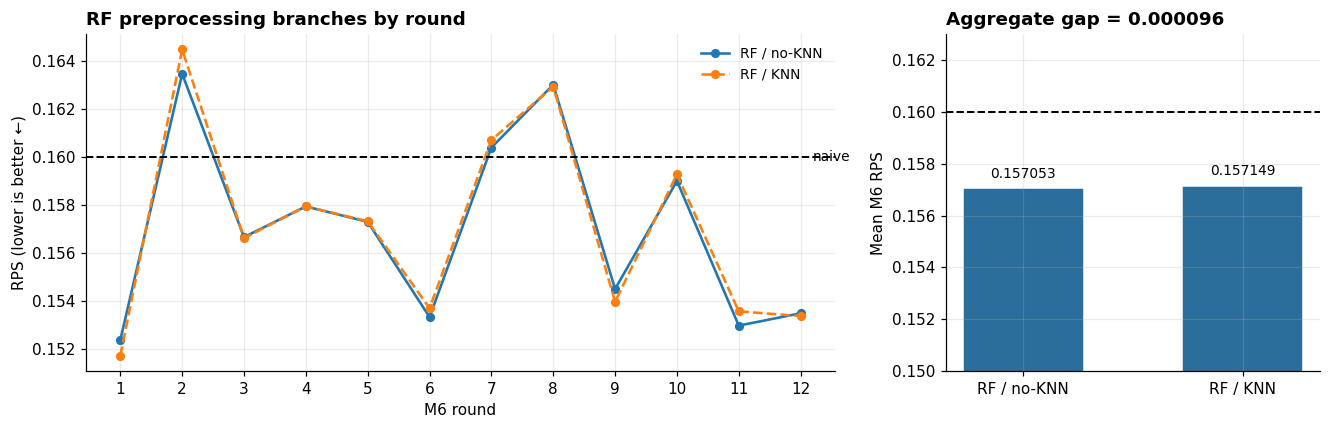

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.0),
                         gridspec_kw={"width_ratios": [2, 1]})
ax = axes[0]
for model, style in [("RF / no-KNN", "-"), ("RF / KNN", "--")]:
    block = by_round[by_round["model"] == model]
    ax.plot(block["round"], block["rps"], marker="o", ms=5, lw=1.7, ls=style, label=model)
ax.axhline(NAIVE, color="black", ls="--", lw=1.3); ax.text(12.2, NAIVE, "naive", va="center", fontsize=9)
ax.set_xticks(range(1, 13)); ax.set_xlabel("M6 round"); ax.set_ylabel("RPS (lower is better ←)")
ax.set_title("RF preprocessing branches by round", fontweight="bold", loc="left")
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
pair = metrics[metrics["model"].isin(["RF / no-KNN", "RF / KNN"])]
ax.bar(pair["model"], pair["rps"], color=FEATURE_C, edgecolor="white", width=0.55)
ax.axhline(NAIVE, color="black", ls="--", lw=1.3)
for i, value in enumerate(pair["rps"]):
    ax.text(i, value + 0.0004, f"{value:.6f}", ha="center", fontsize=9)
ax.set_ylim(0.150, 0.163); ax.set_ylabel("Mean M6 RPS")
gap = abs(pair["rps"].iloc[0] - pair["rps"].iloc[1])
ax.set_title(f"Aggregate gap = {gap:.6f}", fontweight="bold", loc="left")
plt.tight_layout(); plt.show()

---
## H. Chronos-2: copula vs independent sampling — **MEDIUM (sensitivity)**

**What it shows.** Round-by-round RPS for the two Chronos-2 scenario-generation methods.

**Why it may be useful.** It isolates the effect of modelling cross-asset and temporal
dependence in post-processing, holding the underlying foundation model fixed.

**Type:** sensitivity.

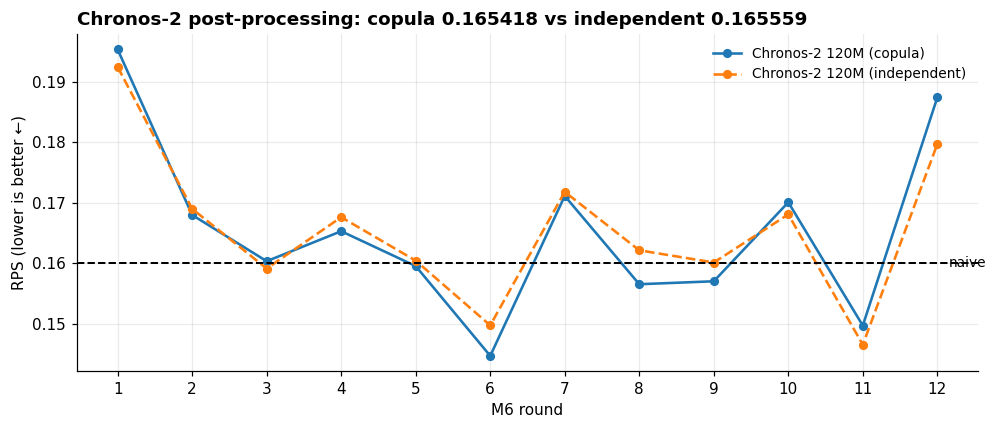

In [9]:
fig, ax = plt.subplots(figsize=(9.2, 4.0))
for model, style in [("Chronos-2 120M (copula)", "-"), ("Chronos-2 120M (independent)", "--")]:
    block = by_round[by_round["model"] == model]
    ax.plot(block["round"], block["rps"], marker="o", ms=5, lw=1.7, ls=style, label=model)
ax.axhline(NAIVE, color="black", ls="--", lw=1.3); ax.text(12.15, NAIVE, "naive", va="center", fontsize=9)
ax.set_xticks(range(1, 13)); ax.set_xlabel("M6 round"); ax.set_ylabel("RPS (lower is better ←)")
overall = metrics.set_index("model")["rps"]
ax.set_title("Chronos-2 post-processing: copula "
             f"{overall['Chronos-2 120M (copula)']:.6f} vs independent "
             f"{overall['Chronos-2 120M (independent)']:.6f}", fontweight="bold", loc="left")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

---
## I. Chronos-2 copula vs independent *cumulative RMSE* — **NOT AVAILABLE**

This diagnostic was requested but **cannot be produced from retained artifacts**.

Both `scripts/evaluate_chronos2_independent_sampling.py` and
`scripts/evaluate_chronos2_spatiotemporal_copula.py` persist only the resulting quintile
probabilities, the RPS tables and the copula diagnostics. The 1,000-scenario arrays
(100 assets x 1,000 scenarios x 20 days) are built in memory and discarded, so there is
no saved object from which to compute cumulative-return point forecasts for either
post-processing method.

Producing it would require regenerating both scenario experiments from the retained
native quantiles. That has **not** been done here. Panel J below therefore covers
mean-vs-median only for the two trajectory-sampling TSFMs, and the Chronos-2 entry in
panel F is restricted to its native median daily forecast.

---
## J. Mean vs median point forecasts — **MEDIUM**

**What it shows.** The difference in cumulative RMSE between using the sampled
distribution's mean and its median as the point forecast, by horizon.

**Why it may be useful.** A systematic gap would say something about skewness in the
predictive distribution. The scale of the y-axis is the point: the differences are
around 1e-4, i.e. negligible.

**Type:** sensitivity — likely droppable.

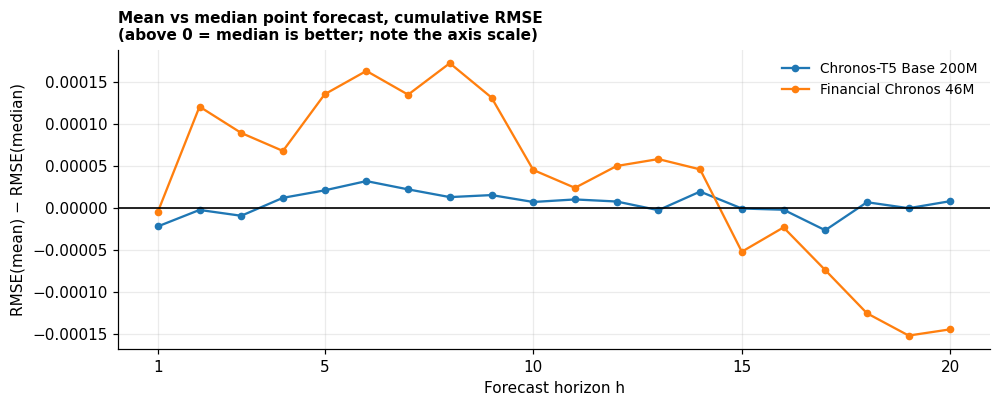

In [10]:
fig, ax = plt.subplots(figsize=(9.2, 3.8))
for model in ["Chronos-T5 Base 200M", "Financial Chronos 46M"]:
    block = rmse[(rmse["model"] == model) & (rmse["rmse_type"] == "cumulative")]
    wide = block.pivot(index="horizon", columns="point_forecast", values="rmse")
    ax.plot(wide.index, wide["mean"] - wide["median"], marker="o", ms=4, lw=1.5, label=model)
ax.axhline(0, color="black", lw=1.1)
ax.set_xticks([1, 5, 10, 15, 20]); ax.set_xlabel("Forecast horizon h")
ax.set_ylabel("RMSE(mean) − RMSE(median)")
ax.set_title("Mean vs median point forecast, cumulative RMSE\n"
             "(above 0 = median is better; note the axis scale)",
             fontweight="bold", loc="left", fontsize=10)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

---
## K. Cumulative RMSE at 5 / 10 / 15 / 20 days — **MEDIUM**

**What it shows.** The same cumulative RMSE as panel F, read at the four retained
horizons, against the zero-forecast floor.

**Why it may be useful.** A compact table-like view for the report if the full horizon
curve is too much detail. Largely redundant with F — probably keep one, not both.

**Type:** diagnostic.

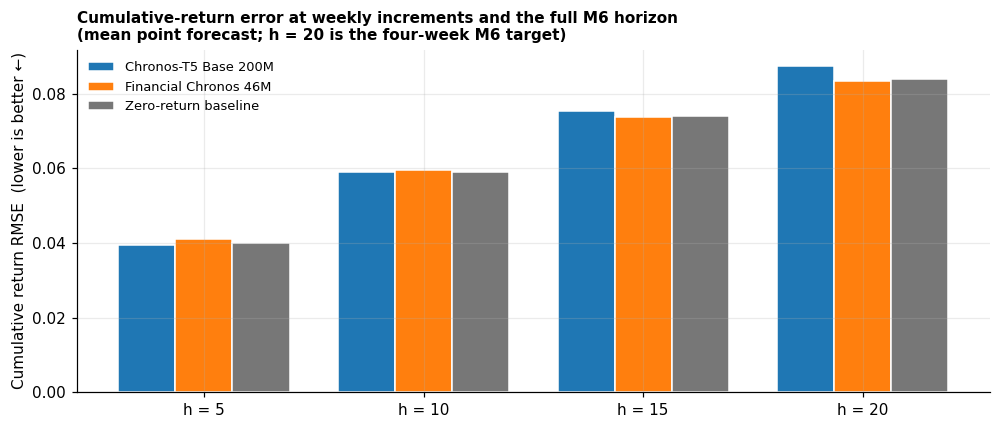

In [11]:
sel = rmse[(rmse["rmse_type"] == "cumulative") & (rmse["horizon"].isin([5, 10, 15, 20]))]
wide = sel[sel["point_forecast"].isin(["mean", "zero"])].pivot(
    index="horizon", columns="model", values="rmse")
fig, ax = plt.subplots(figsize=(9.2, 4.0))
x = np.arange(4); width = 0.26
for i, column in enumerate(wide.columns):
    ax.bar(x + (i - 1) * width, wide[column], width, label=column,
           color="#777" if column == "Zero-return baseline" else None, edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels([f"h = {h}" for h in wide.index])
ax.set_ylabel("Cumulative return RMSE  (lower is better ←)")
ax.set_title("Cumulative-return error at weekly increments and the full M6 horizon\n"
             "(mean point forecast; h = 20 is the four-week M6 target)",
             fontweight="bold", loc="left", fontsize=10)
ax.legend(frameon=False, fontsize=8.5)
plt.tight_layout(); plt.show()

---
## L. Accuracy vs RPS — **MEDIUM**

**What it shows.** Each model's exact-quintile accuracy against its RPS, with the naive
point marked.

**Why it may be useful.** It answers a specific question directly: models with similar
RPS need not have similar accuracy, and vice versa. Chronos-2 (copula) is the
interesting case — competitive accuracy, poor RPS.

**Type:** diagnostic / interpretive.

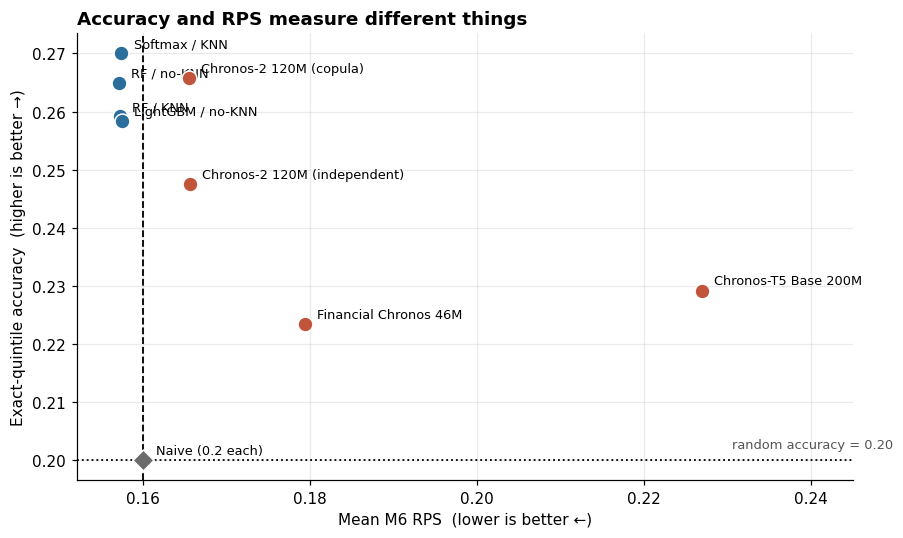

In [12]:
fig, ax = plt.subplots(figsize=(8.4, 5.0))
for _, row in metrics.iterrows():
    ax.scatter(row["rps"], row["accuracy"], s=95, color=COLOR[row["model"]],
               edgecolor="white", zorder=3,
               marker="D" if row["family"] == "Benchmark" else "o")
    ax.annotate(row["model"], (row["rps"], row["accuracy"]),
                textcoords="offset points", xytext=(8, 4), fontsize=8.4)
ax.axvline(NAIVE, color="black", ls="--", lw=1.2)
ax.axhline(0.2, color="black", ls=":", lw=1.2)
ax.text(0.2305, 0.202, "random accuracy = 0.20", fontsize=8.5, color="#555")
ax.set_xlabel("Mean M6 RPS  (lower is better ←)")
ax.set_ylabel("Exact-quintile accuracy  (higher is better →)")
ax.set_xlim(0.152, 0.245)
ax.set_title("Accuracy and RPS measure different things", fontweight="bold", loc="left")
plt.tight_layout(); plt.show()

---
## M. Accuracy by M6 round — **MEDIUM**

**What it shows.** Exact-quintile accuracy per round for the leading models.

**Why it may be useful.** Shows whether accuracy is stable or spiky. With only 100 assets
per round, single-round accuracy is noisy — that is itself worth seeing before relying
on it.

**Type:** sensitivity — likely droppable.

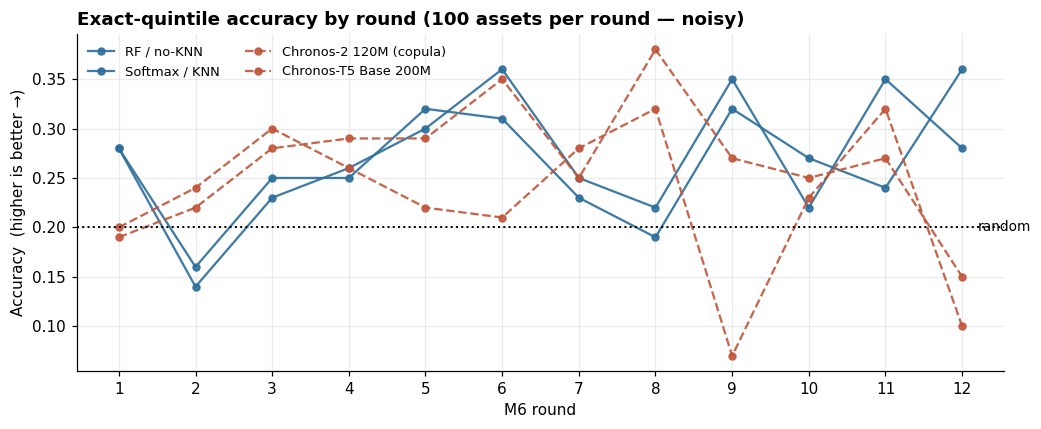

In [13]:
fig, ax = plt.subplots(figsize=(9.6, 4.0))
for model in ["RF / no-KNN", "Softmax / KNN", "Chronos-2 120M (copula)", "Chronos-T5 Base 200M"]:
    block = by_round[by_round["model"] == model]
    ax.plot(block["round"], block["accuracy"], marker="o", ms=4.5, lw=1.5,
            color=COLOR[model], ls="-" if ev.FAMILY[model] == "Feature-based" else "--",
            label=model, alpha=0.9)
ax.axhline(0.2, color="black", ls=":", lw=1.3)
ax.text(12.2, 0.2, "random", va="center", fontsize=9)
ax.set_xticks(range(1, 13)); ax.set_xlabel("M6 round")
ax.set_ylabel("Accuracy  (higher is better →)")
ax.set_title("Exact-quintile accuracy by round (100 assets per round — noisy)",
             fontweight="bold", loc="left")
ax.legend(frameon=False, fontsize=8.5, ncol=2)
plt.tight_layout(); plt.show()

---
## N. Sample-count sensitivity — **OPTIONAL**

**What it shows.** An already-completed experiment in `Testing_What_Works/`: how the
number of sampled trajectories (100 / 300 / 500 / 1000) affects TSFM RPS.

**Why it may be useful.** It supports the claim that the TSFM results are not an artifact
of using only 100 samples. Nothing was rerun to produce this.

**Type:** sensitivity.

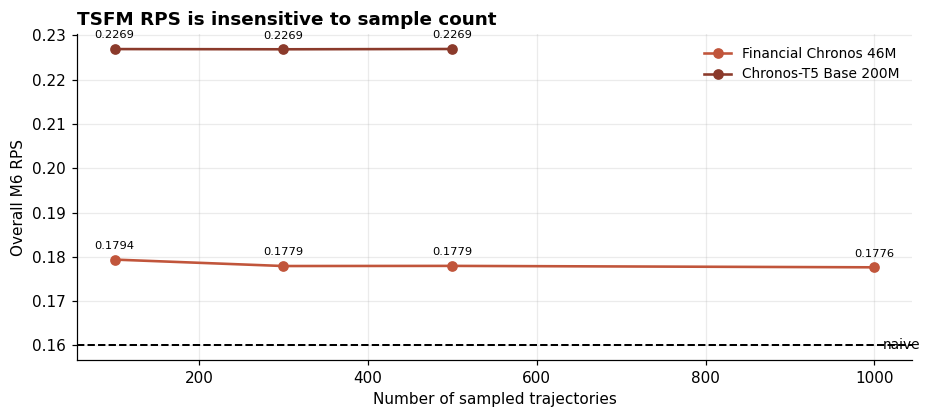

In [14]:
fig, ax = plt.subplots(figsize=(8.6, 3.9))
for path, label, colour in [
        (ROOT / "Testing_What_Works/sample_count_test_results.csv", "Financial Chronos 46M", TSFM_C),
        (ROOT / "Testing_What_Works/sample_count_test_base_300_500_results.csv", "Chronos-T5 Base 200M", "#8B3A2B")]:
    table = pd.read_csv(path)
    ax.plot(table["Sample Count"], table["Overall RPS"], marker="o", ms=6, lw=1.7,
            color=colour, label=label)
    for _, row in table.iterrows():
        ax.annotate(f"{row['Overall RPS']:.4f}", (row["Sample Count"], row["Overall RPS"]),
                    textcoords="offset points", xytext=(0, 7), fontsize=7.5, ha="center")
ax.axhline(NAIVE, color="black", ls="--", lw=1.3)
ax.text(1010, NAIVE, "naive", va="center", fontsize=9)
ax.set_xlabel("Number of sampled trajectories"); ax.set_ylabel("Overall M6 RPS")
ax.set_title("TSFM RPS is insensitive to sample count", fontweight="bold", loc="left")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

---
## O. Forecast dispersion diagnostic — **OPTIONAL**

**What it shows.** A retained diagnostic: mean maximum probability (confidence) and mean
predictive entropy per round for the two trajectory TSFMs, against the maximum possible
entropy for five classes.

**Why it may be useful.** It independently corroborates the overconfidence story in
panel C using an artifact produced during the original evaluation stage.

**Type:** diagnostic.

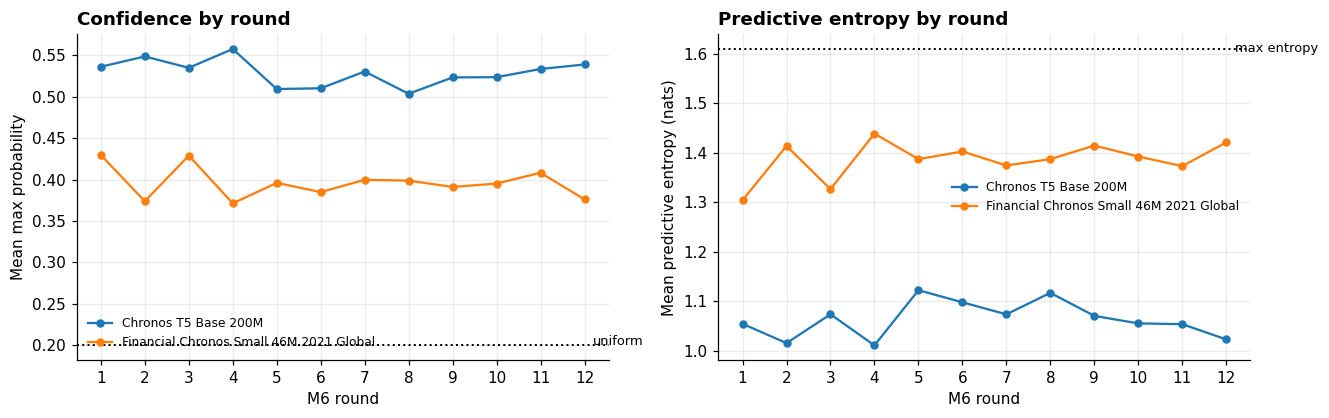

In [15]:
dispersion = pd.read_csv(ROOT / "Results/Evaluation/forecast_dispersion_diagnostics.csv")
fig, axes = plt.subplots(1, 2, figsize=(12.2, 3.9))
for model, group in dispersion.groupby("model"):
    axes[0].plot(group["round"], group["mean_max_probability"], marker="o", ms=4.5, lw=1.5, label=model)
    axes[1].plot(group["round"], group["mean_probability_entropy"], marker="o", ms=4.5, lw=1.5, label=model)
axes[0].axhline(0.2, color="black", ls=":", lw=1.3)
axes[0].text(12.2, 0.205, "uniform", va="center", fontsize=8.5)
axes[0].set_ylabel("Mean max probability"); axes[0].set_title("Confidence by round", fontweight="bold", loc="left")
axes[1].axhline(dispersion["max_possible_entropy"].iloc[0], color="black", ls=":", lw=1.3)
axes[1].text(12.2, dispersion["max_possible_entropy"].iloc[0], "max entropy", va="center", fontsize=8.5)
axes[1].set_ylabel("Mean predictive entropy (nats)")
axes[1].set_title("Predictive entropy by round", fontweight="bold", loc="left")
for ax in axes:
    ax.set_xticks(range(1, 13)); ax.set_xlabel("M6 round"); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

---
## P. Incomplete experiment: LightGBM / KNN — **OPTIONAL, clearly labelled**

LightGBM/KNN is **not** a complete 12-round model and appears in no aggregate above.
It was stopped at round 11 (2022-12-09) when the released cross-sectional probability
adjustment produced a value of −0.001070, and its forecasts were not retained, so there
is nothing to plot. Recorded here only so the gap in the model grid is explicit.

In [16]:
status = pd.read_csv(ROOT / "Results/Evaluation/feature_baseline_m6_rps.csv")
status[["model", "variant", "status", "failed_round", "failed_origin",
        "failure_reason", "rounds_completed", "mean_tuning_rps"]]

,model,variant,status,failed_round,failed_origin,failure_reason,rounds_completed,mean_tuning_rps
0,lgbm,knn,stopped_invalid_probability,11.0,2022-12-09,probability below 0 (min -0.001070),10,0.155838
1,lgbm,no_knn,complete,NaN,NaN,NaN,12,0.155950
2,rf,knn,complete,NaN,NaN,NaN,12,0.155624
3,rf,no_knn,complete,NaN,NaN,NaN,12,0.155614


---
## Summary of what the exploratory metrics suggest

Read conservatively — these are 12 rounds of 100 assets, and most differences are small.

1. **The families separate on calibration far more than on discrimination.** Macro
   ROC-AUC spans only 0.534–0.612 across all eight models, but ECE spans 0.005–0.300.
   The TSFMs are not mainly failing to *rank* assets; they are failing to state
   *how sure* they are. Chronos-T5 predicts with mean confidence 0.529 while being right
   22.9% of the time.

2. **Accuracy and RPS do not agree.** Chronos-2 (copula) achieves accuracy 0.266 —
   indistinguishable from RF/no-KNN's 0.265 — yet its RPS is 0.1654 against RF's 0.1571.
   Accuracy sees only the argmax; RPS sees the whole ordered distribution. This is a good
   argument for keeping RPS primary and reporting accuracy only as a secondary check.

3. **Q2 is hard for everyone** (AUC 0.478–0.558) while the extreme quintiles Q1 and Q5
   are the most separable for the feature-based models (≈0.64). Plausible: extreme
   four-week movers are easier to anticipate than assets just below the median.

4. **The TSFMs have essentially no numerical point-forecast skill.** Daily RMSE at every
   horizon sits on the zero-forecast floor, and Chronos-T5's cumulative RMSE is *worse*
   than forecasting zero at every horizon beyond about 5 days. Cumulative error grows
   roughly like √h, which is what pure accumulation of unpredicted noise looks like.

5. **Mean vs median makes no material difference** (~1e-4 in cumulative RMSE). Do not
   read anything into it.

6. **Daily RMSE rises only modestly with horizon** (≈0.0178 → 0.0220) and
   non-monotonically — h = 10 is lower than h = 1. That pattern tracks realised
   volatility across the calendar, not forecast decay, so it should not be described as
   horizon deterioration. Cumulative RMSE does rise steadily, but so does the zero-forecast
   floor.

7. **RMSE and RPS tell partly different stories.** Financial Chronos has slightly better
   cumulative RMSE than Chronos-T5 and also better RPS, but Chronos-2 — the best TSFM on
   RPS — cannot be compared on cumulative RMSE at all. The RPS ordering is driven mainly
   by calibration of the quintile distribution, not by return-forecast accuracy.

**Everything above is exploratory.** No metric or figure has been selected for the final
report.